**Name:**

# Synthetic data generation

> 인용구 추가



In [24]:
K = 3
n = 1000
max_iter = 10

In [25]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n, centers=K, n_features=2)

In [26]:
import pandas as pd

df = pd.concat([pd.DataFrame(X), pd.Series(y)], axis=1)
df.head()

df.columns = ['x1', 'x2', 'y']
df.loc[df['y'] == 2, 'color'] = 'green'
df.loc[df['y'] == 1, 'color'] = 'red'
df.loc[df['y'] == 0, 'color'] = 'blue'

<Axes: xlabel='x1', ylabel='x2'>

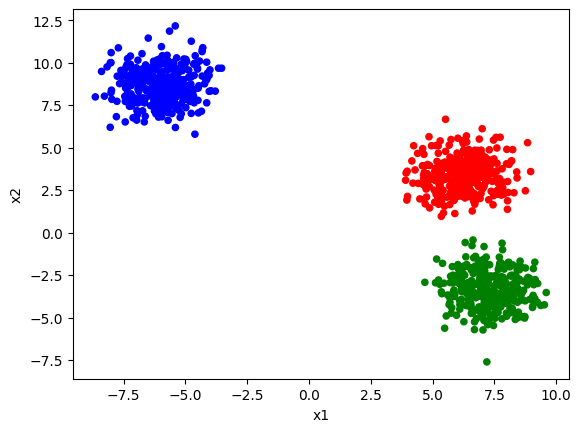

In [27]:
df.plot.scatter('x1', 'x2', c='color')

# Gaussian mixture clustering with 2-dimensional data points

E-step:

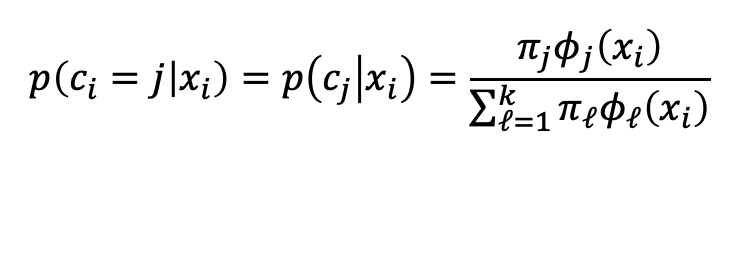


M-step:

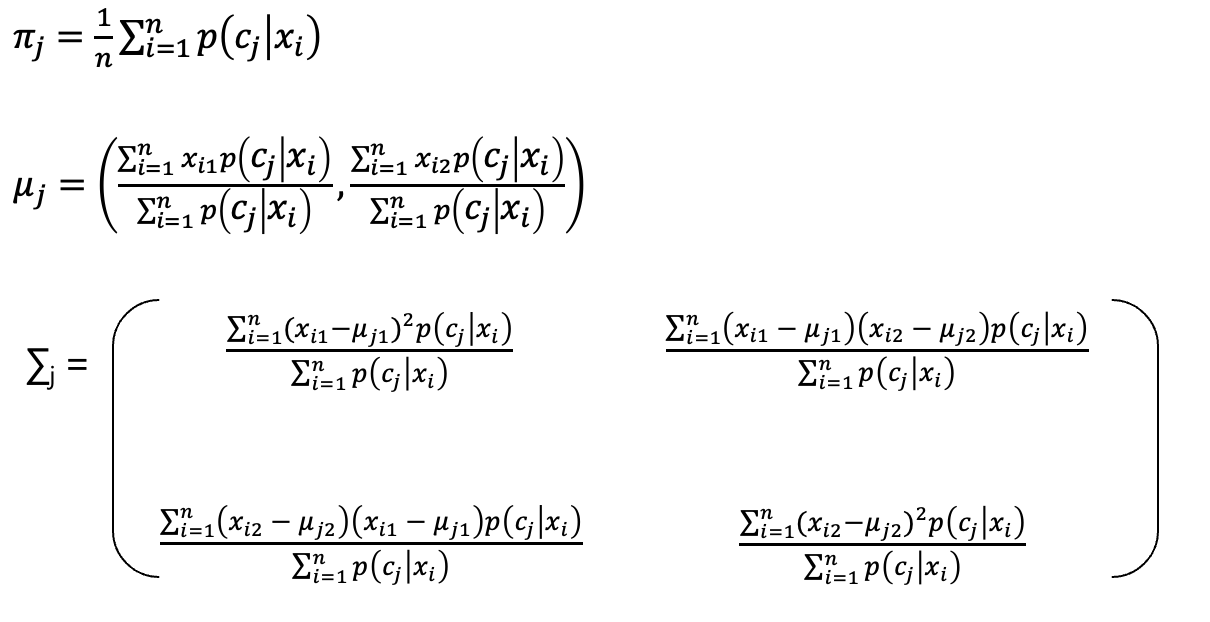

# PySpark Implementation

In [28]:
from pyspark.sql import SparkSession

spark = SparkSession.builder\
  .master("local[*]")\
  .getOrCreate()
sc = spark.sparkContext

In [29]:
import numpy as np

def gaussian_2d(x, means, cov):
    """
    Computes the Gaussian distribution function for 2D data.

    Parameters:
        x (np.ndarray): A 2D point, numpy array of shape (2,).
        mean (np.ndarray): The mean vector, numpy array of shape (2,).
        cov (np.ndarray): The covariance matrix, numpy array of shape (2, 2).

    Returns:
        float: The value of the Gaussian distribution at the given point.
    """
    det_cov = np.linalg.det(cov)  # determinant of the covariance matrix
    inv_cov = np.linalg.inv(cov)  # inverse of the covariance matrix
    norm_factors = 1 / (2 * np.pi * np.sqrt(det_cov))  # normalization factor

    # Compute Gaussian values for each mean-covariance pair
    diffs = x - means  # Shape (n, 2)
    exponents = -0.5 * np.einsum('ij,ijk,ik->i', diffs, inv_cov, diffs)  # Shape (n,)

    return norm_factors * np.exp(exponents)

In [30]:
rdd = sc.parallelize(X)

In [31]:
import numpy as np

#파라미터 초기화
#알고리즘을 시작하려면 일단 대충 정답을 찍고 시작해야하니까
#랜덤으로 중심점 3개를 찍는다.(-10~10 사이)
mean = np.random.random((K,2)) * 20 - 10
#cov(공분산)는 단위 행렬로 3개 만든다.
cov = np.array([np.eye(2) for _ in range(K)])
#각 클러스터가 선택될 확률 pi도 랜덤으로 정하고, 합이 1이 되게 나눈다.
pi = np.random.random((K,))
pi = pi / pi.sum()

In [32]:
#E-step에 사용되는. "너 어디 소속이니?"
#데이터 하나하나를 보고 몇번 클러스터인지 확률을 매기는 과정
def compute_pcx(x, pi, mean, cov):
  #거리에 따른 확률을 구하고, 클러스터 가중치(pi)를 곱함
  pcx = pi * gaussian_2d(x, mean, cov)
  #확률의 합이 1이 되도록 나눔(정규화)
  pcx = pcx / pcx.sum()
  return pcx

In [33]:
for _ in range(max_iter):
  b_pi = sc.broadcast(pi)
  b_mean = sc.broadcast(mean)
  b_cov = sc.broadcast(cov)

  # E-step
  #분산된 데이터 각각에 대해 함수를 적용
  #결과 : (원래 데이터 x, [소속 확률 3개])
  pcx_rdd = rdd.map(lambda x: (x, compute_pcx(x, b_pi.value, b_mean.value, b_cov.value)))

  # M-step
  # (key,value)형태로 변환 후 합치기
  # key: 클러스터의 인덱스(0,1,2)
  # value: (가중치, 가중치*좌표, 가중치*좌표외적)
  momentum_rdd = pcx_rdd.flatMap(lambda p: [(i, (p[1][i], p[1][i] * p[0], p[1][i]*np.outer(p[0], p[0])))
  for i in range(K)]).reduceByKey(lambda a, b: (a[0]+b[0], a[1]+b[1], a[2]+b[2]))

  #집계된 momentum 데이터를 받아서 수학 공식을 적용해 $\pi, \mu, \Sigma$ 업데이트
  mo = momentum_rdd.collect()

  # post-process
  for j, t in mo:
    #t[0]: N_k(가중치 합)
    #t[1]: Sum_x(가중 좌표 합)
    #t[2]: Sum_xxT(가중 외적 합)

    #1. pi는 (이 클러스터의 지분율):(가중치 합) / (전체 데이터 개수)
    pi[j] = t[0] / n

    #2. mean은 (새로운 중심):(가중 좌표 합) / (가중치 합)
    mean[j] = t[1] / t[0]

    #3. cov는 (새로운 공분산): 제.평-평.제
    cov[j] = (t[2] / t[0]) - np.outer(mean[j], mean[j])

# Evaluation

In [34]:
y_pred = [ np.argmax(pi * gaussian_2d(x, mean, cov)) for x in X ]

In [35]:
df = pd.concat([pd.DataFrame(X), pd.Series(y_pred)], axis=1)
df.head()

df.columns = ['x1', 'x2', 'y']
df.loc[df['y'] == 2, 'color'] = 'green'
df.loc[df['y'] == 1, 'color'] = 'red'
df.loc[df['y'] == 0, 'color'] = 'blue'

<Axes: xlabel='x1', ylabel='x2'>

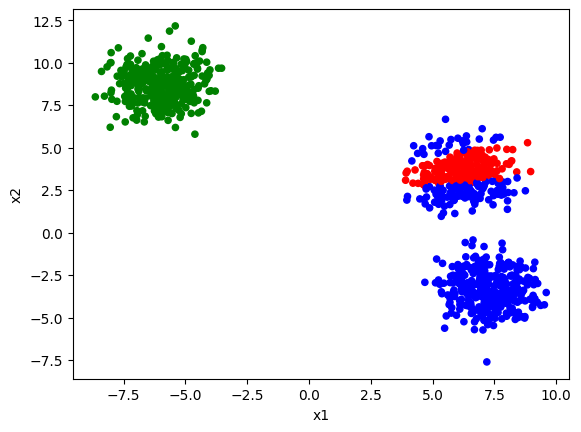

In [36]:
df.plot.scatter('x1', 'x2', c='color')